✅  Artifacts loaded.
    Model     : Gradient Boosting
    Features  : ['avg_grade', 'G2', 'Fedu', 'paid', 'absences', 'G1', 'Fjob', 'famsize', 'Dalc', 'reason']
    Test size : 79

  8.1  GRADIENT BOOSTING — FEATURE IMPORTANCE
  Feature  Importance
avg_grade      0.5683
       G2      0.1117
 absences      0.0958
       G1      0.0562
   reason      0.0385
     Dalc      0.0335
  famsize      0.0322
     Fedu      0.0296
     Fjob      0.0264
     paid      0.0078


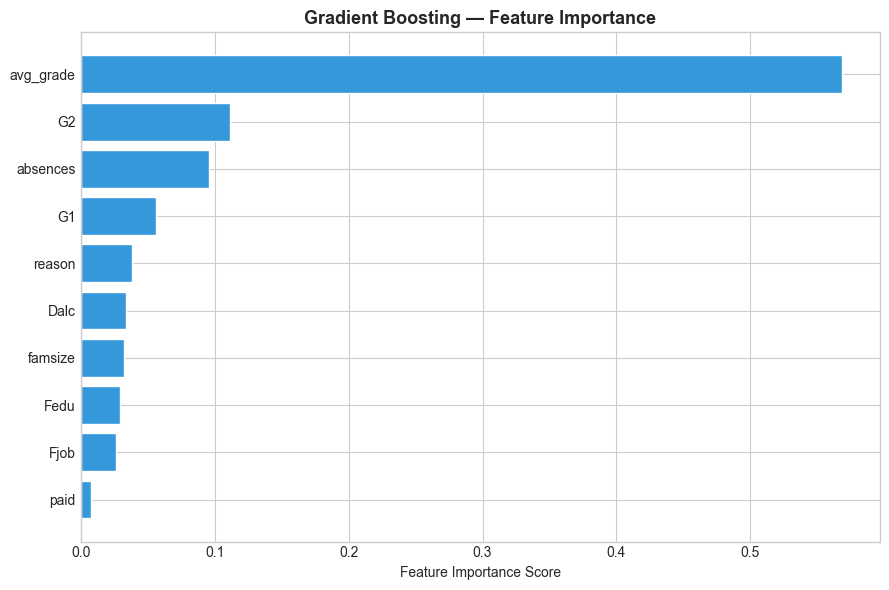


  Plot saved → ../docs/gb_feature_importance.png

  8.2  LIME EXPLAINER SETUP
  ⚠️   lime not installed. Run: pip install lime
  ⚠️   Skipping LIME explanations — explainer not available.

✅  Stage 8 complete. LIME plots saved to ../docs/
    Next  : python stage9_deployment.py  (Abhi)


In [1]:
# =============================================================================
# STAGE 8 — Model Interpretation & Explainability (LIME)
# -----------------------------------------------------------------------------
# Project: Student Performance Prediction & Early Intervention (#23)
# Team   : Abhi | Aparna | Jia  |  Predictive Analytics 2025-26
# Run    : python stage8_explainability.py   (after stage7)
# Input  : ../models/gradient_boosting_model.pkl
#          ../models/selected_features.pkl
#          ../data/test_set.csv
#          ../data/train_scaled.csv
# Output : LIME plots saved to ../docs/
# =============================================================================

import os
import warnings
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

DOCS_DIR = "../docs"
os.makedirs(DOCS_DIR, exist_ok=True)


# ── Load artifacts ────────────────────────────────────────────────────────────
def load_artifacts():
    required = {
        "../models/gradient_boosting_model.pkl": "gradient_boosting_model.pkl",
        "../models/selected_features.pkl"      : "selected_features.pkl",
        "../data/test_set.csv"                 : "test_set.csv",
        "../data/train_scaled.csv"             : "train_scaled.csv",
    }
    for path, name in required.items():
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"{name} not found.\n"
                "Please run stage6_model_building.py first."
            )

    model             = joblib.load("../models/gradient_boosting_model.pkl")
    selected_features = joblib.load("../models/selected_features.pkl")

    test_df  = pd.read_csv("../data/test_set.csv")
    train_df = pd.read_csv("../data/train_scaled.csv")

    X_test   = test_df[selected_features].values
    y_test   = test_df["pass"].values
    X_train  = train_df[selected_features].values

    print("✅  Artifacts loaded.")
    print(f"    Model     : Gradient Boosting")
    print(f"    Features  : {selected_features}")
    print(f"    Test size : {len(y_test)}\n")
    return model, selected_features, X_train, X_test, y_test


# ── 8.1  Feature Importance (built-in) ───────────────────────────────────────
def plot_feature_importance(model, selected_features):
    print("=" * 55)
    print("  8.1  GRADIENT BOOSTING — FEATURE IMPORTANCE")
    print("=" * 55)

    imp_df = (
        pd.DataFrame({
            "Feature"   : selected_features,
            "Importance": model.feature_importances_,
        })
        .sort_values("Importance", ascending=True)
    )

    print(imp_df.sort_values("Importance", ascending=False)
               .round(4).to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(imp_df["Feature"], imp_df["Importance"],
            color="#3498db", edgecolor="white")
    ax.set_title("Gradient Boosting — Feature Importance",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Feature Importance Score")
    plt.tight_layout()
    out = f"{DOCS_DIR}/gb_feature_importance.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  Plot saved → {out}")


# ── 8.2  LIME Setup ───────────────────────────────────────────────────────────
def setup_lime(model, selected_features, X_train):
    print("\n" + "=" * 55)
    print("  8.2  LIME EXPLAINER SETUP")
    print("=" * 55)
    try:
        import lime
        import lime.lime_tabular
    except ImportError:
        print("  ⚠️   lime not installed. Run: pip install lime")
        return None

    explainer = lime.lime_tabular.LimeTabularExplainer(
        X_train,
        feature_names=selected_features,
        class_names=["Fail", "Pass"],
        mode="classification",
        random_state=42,
    )
    print("  ✅  LIME explainer ready.")
    return explainer


# ── 8.3  Explain Individual Students ─────────────────────────────────────────
def explain_students(model, explainer, selected_features,
                     X_test, y_test, n_fail=2, n_pass=1):
    if explainer is None:
        print("  ⚠️   Skipping LIME explanations — explainer not available.")
        return

    print("\n" + "=" * 55)
    print("  8.3  LIME PER-STUDENT EXPLANATIONS")
    print("=" * 55)

    y_pred       = model.predict(X_test)
    fail_indices = np.where(y_pred == 0)[0]
    pass_indices = np.where(y_pred == 1)[0]

    print(f"  Predicted Fail : {len(fail_indices)} students")
    print(f"  Predicted Pass : {len(pass_indices)} students")

    # Explain failing students
    for idx in fail_indices[:n_fail]:
        _explain_one(model, explainer, selected_features,
                     X_test, y_test, idx, label="FAIL")

    # Explain passing students
    for idx in pass_indices[:n_pass]:
        _explain_one(model, explainer, selected_features,
                     X_test, y_test, idx, label="PASS")


def _explain_one(model, explainer, selected_features,
                 X_test, y_test, idx, label):
    exp    = explainer.explain_instance(
        X_test[idx], model.predict_proba, num_features=8
    )
    proba  = model.predict_proba([X_test[idx]])[0]
    actual = "Pass" if y_test[idx] == 1 else "Fail"

    print(f"\n  ── Student #{idx}  |  Predicted: {label}  |  "
          f"Actual: {actual} ──")
    print(f"  Probability → Fail: {proba[0]:.2f}  |  Pass: {proba[1]:.2f}")
    print("  Top factors:")
    for feat, weight in exp.as_list():
        arrow = "↑ raises fail risk" if weight < 0 else "↓ lowers fail risk"
        print(f"    {feat:<35}  {weight:+.4f}  ({arrow})")

    # Counselor tip
    if label == "FAIL":
        print("\n  📋  Counselor tip:")
        factors = exp.as_list()
        risky = [f for f, w in factors if w < 0]
        if risky:
            print(f"    Focus intervention on: {risky[:3]}")

    # Save plot
    fig = exp.as_pyplot_figure()
    fig.suptitle(f"LIME — Student #{idx} (Predicted: {label})",
                 fontweight="bold")
    plt.tight_layout()
    out = f"{DOCS_DIR}/lime_student_{idx}_{label.lower()}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Plot saved → {out}")


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    model, selected_features, X_train, X_test, y_test = load_artifacts()
    plot_feature_importance(model, selected_features)
    explainer = setup_lime(model, selected_features, X_train)
    explain_students(model, explainer, selected_features,
                     X_test, y_test, n_fail=2, n_pass=1)

    print(f"\n✅  Stage 8 complete. LIME plots saved to {DOCS_DIR}/")
    print("    Next  : python stage9_deployment.py  (Abhi)")
